In [1]:
import os
from pathlib import Path
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr 
import hydromt
from hydromt._utils import log
from hydromt_sfincs import SfincsModel
from sfincs_utils import run_sfincs
from hydromt import DataCatalog
from turtle import pd
from shapely.geometry import Point
import pandas as pd
import numpy as np
from pyproj import Transformer

log.initialize_logging()
log.set_log_level(log_level=20)

proj = ccrs.PlateCarree() # plot projection

main_dir = Path(r"C:\PhD\SFINCS\SFINCS_cloned\input")

# 1a: Configure model - data catalog -----------------------------------------------------
catalog = hydromt.DataCatalog(data_libs = ['data_catalog_v1.yml', 'artifact_data']) #, 'deltares_data'])
# can possibly take things out of my own data_catalog if i use the predefined ones 

# 1b: Configure model - model domain ----------------------------------------------------
deltas = catalog.get_geodataframe('40_delta_polygons')

# Filter specific deltas by BasinID2
target_basin_id = 620947 # small delta in australia 
# target_basin_id = 908572
# target_basin_id = 2098785 # rhone 
# target_basin_id = 1416812 # zambezi, slighlty changed geojson to include whole coast 

region = deltas[deltas['BasinID2'] == target_basin_id]

# Load the hydrobasins that intersect with the selected delta
gdf_basin = catalog.get_geodataframe(
    'hydrobasins_global',
    geom=region # only load basins that intersect with our region of interest
)

# Initialise model --------------------------------------------------------
root_folder  = Path('C:/PhD/SFINCS/SFINCS_cloned/output') / f'sfincs_{target_basin_id}'
logger_name = 'SFINCS_log'

sf = SfincsModel(
    data_libs= ["data_catalog_v1.yml", "artifact_data"],  # specify which data libraries to use
    root= root_folder,  # specify the root directory for the model
    mode="w+",  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,  # specify whether to write GIS data
)


2026-01-14 09:14:54,267 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-14 09:14:55,416 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-01-14 09:14:55,417 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\lasch\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2026-01-14 09:14:56,777 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading 40_delta_polygons GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\delta_polygons\40_delta_polygons.geojson
2026-01-14 09:14:56,790 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading hydrobasins_global GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\hydrobasins_global.gpkg
2026-01-14 09:14:56,839 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from data_catalog_v1.yml
2026-01-14 09:14:56,888 - hydr

In [2]:
# Print all data source names source names in catalogs
sources = list(catalog.sources.keys())
for i, source in enumerate(sources, 1):
    print(f"{i}. {source}")

1. 40_delta_polygons
2. hydrobasins_global
3. merit
4. gebco
5. esa_worldcover
6. esa_worldcover_mapping
7. gcn250
8. combined_dataset_deltas
9. deltadtm
10. osm_water
11. gtsm_codec_reanalysis_waterlevel_hourly
12. gtsm_reanalysis_2018_hourly_v1
13. gtsm_reanalysis_2018_hourly_v3
14. merit_hydro
15. chelsa
16. chirps_global
17. corine
18. dtu10mdt
19. dtu10mdt_egm96
20. eobs
21. eobs_orography
22. era5
23. era5_hourly
24. era5_daily_zarr
25. era5_hourly_zarr
26. era5_orography
27. gadm_level1
28. gadm_level2
29. gadm_level3
30. gdp_world
31. ghs_smod_2015
32. ghs_pop_2015
33. ghs_pop_2015_54009
34. globcover_2009
35. glw_buffaloes
36. glw_cattle
37. glw_chicken
38. glw_ducks
39. glw_goats
40. glw_horses
41. glw_pigs
42. glw_sheep
43. grdc
44. grip_roads
45. grwl
46. grwl_mask
47. gswo
48. gtsmv3_eu_era5
49. guf_bld_2012
50. hydro_lakes
51. hydro_reservoirs
52. koppen_geiger
53. mdt_cnes_cls18
54. merit_hydro_ihu
55. merit_hydro_index
56. modis_lai
57. osm_coastlines
58. osm_landareas


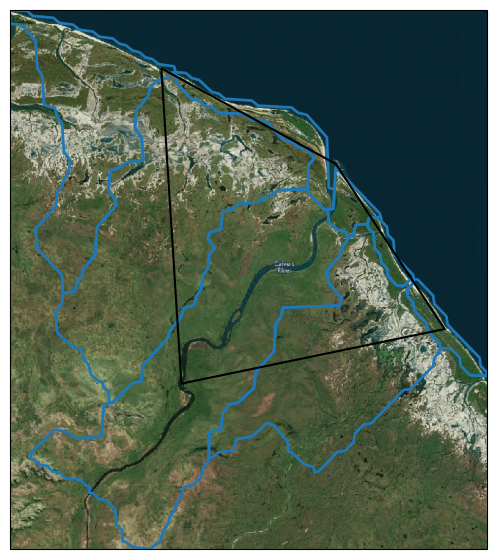

In [3]:
# Plot the initially chosen region (black box), and all the basins (partially) within the region (blue outlines).
# The model domain will be all those river basins plus the coast line.
fig = plt.figure(figsize=(10,7))
ax= plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(),12)

# Plot the hydrobasins
gdf_basin['geometry'].boundary.plot(ax=ax, label='basins', lw=2)
region.boundary.plot(ax=ax,color='k', label='region')
ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)

2026-01-14 09:15:11,356 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading osm_water GeoDataFrame data from P:\wflow_global\hydromt\geography\osm\osm_coastlines-db.gpkg


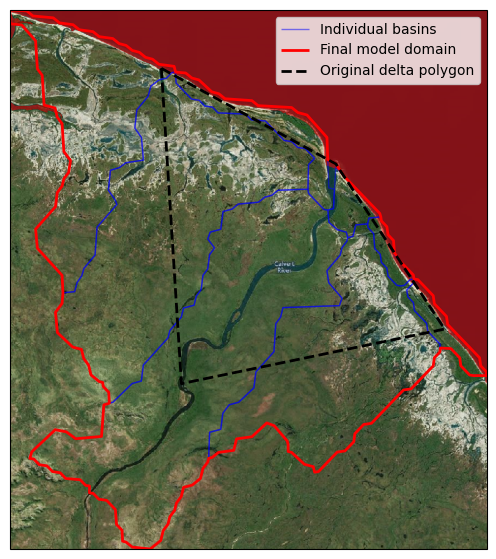

In [4]:
# Create a combined polygon from all the basins that overlap with the delta
dissolved_basins = gdf_basin.dissolve()  # Dissolve all overlapping basins
total_polygon = dissolved_basins.overlay(region, how='union').dissolve()

# Visualize the combined polygon
fig = plt.figure(figsize=(10,7))
ax = plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(), 12)

# Plot the individual basin boundaries 
gdf_basin['geometry'].boundary.plot(ax=ax, label='Individual basins', lw=1, color='blue', alpha=0.5)
total_polygon.boundary.plot(ax=ax, label='Final model domain', lw=2, color='red')
region.boundary.plot(ax=ax, color='k', label='Original delta polygon', lw=2, linestyle='--')

# Load and plot coastlines near the delta region
global_water = catalog.get_geodataframe('osm_water', geom=total_polygon)
global_water.plot(ax=ax, color='red', label='Coastline', alpha = 0.5)

ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)
ax.legend()
plt.show()

2026-01-14 09:15:16,564 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 9 attributes in model config.


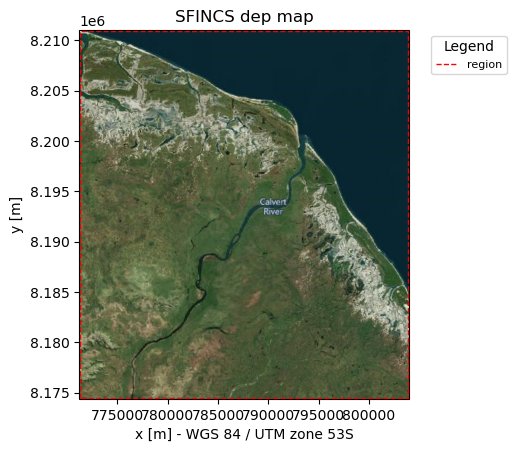

In [5]:
# 2:Define model grid --------------------------------------------------------

# model resolution 
model_res = 100

sf.grid.create_from_region(
    region = {'bbox': total_polygon.to_crs('EPSG:4326').total_bounds},  # use combined polygon for model domain
    res = model_res,
    rotated=False, # non-rotated grid. 
    crs='utm' # automatically the closest UTM zone is selected (unit is in meters), 
)

fig, ax = sf.plot_basemap(plot_region=True,bmap='sat')

2026-01-13 09:05:56,922 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading deltadtm RasterDataset data from C:\PhD\SFINCS\SFINCS_cloned\input\DeltaDTM\deltadtm_v1_1.vrt
2026-01-13 09:06:01,440 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt


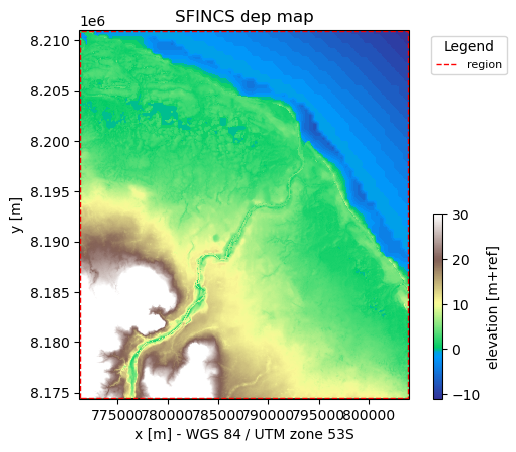

In [15]:
# 3: Build model elevation --------------------------------------------------------
elevation_list = [
    {'elevation': 'deltadtm', 'zmin': 0.001},
    # {'elevation': 'merit', 'zmin': 0.001},  
    {'elevation': 'gebco'}
]

dep = sf.elevation.create(elevation_list = elevation_list)
sf.grid

# Plot the elevation on top of the model region and satellite image. The variable argument sets which model variable to plot
_ = sf.plot_basemap(variable='dep', bmap='sat', plot_region=True)

2026-01-14 09:15:19,828 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc
2026-01-14 09:15:20,700 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt


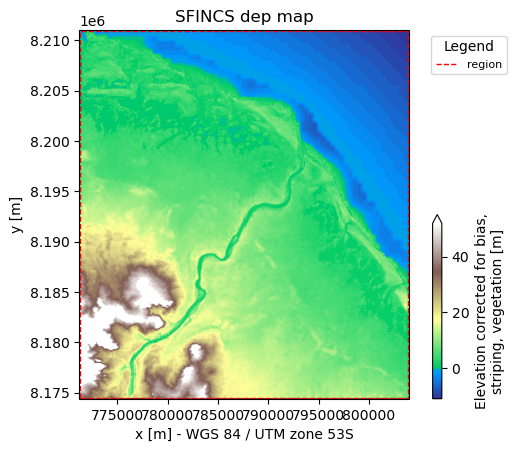

In [6]:
elevation_list = [
    # {'elevation': 'deltadtm', 'zmin': 0.001},
    {'elevation': 'merit', 'zmin': 0.001},  # merit looks higher resolution
    {'elevation': 'gebco'}
]

dep = sf.elevation.create(elevation_list = elevation_list)
sf.grid

# Plot the elevation on top of the model region and satellite image. The variable argument sets which model variable to plot
_ = sf.plot_basemap(variable='dep', bmap='sat', plot_region=True)

2026-01-14 09:16:24,154 - hydromt.hydromt_sfincs.components.grid.mask - mask - INFO - 0 gaps outside valid elevation range < 10.0 km2.
2026-01-14 09:16:24,211 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 2 attributes in model config.
2026-01-14 09:16:24,405 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask


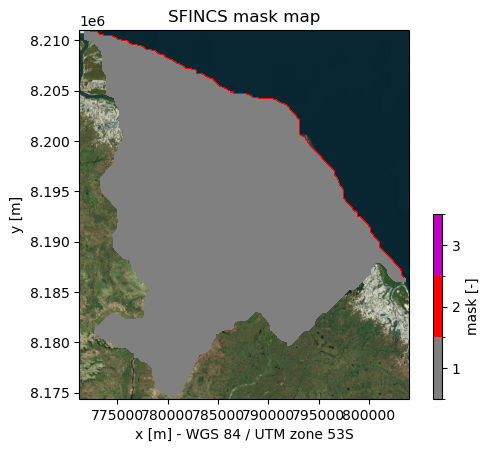

In [7]:
# 4: Define active cells --------------------------------------------------------

# Define active cells within the combined basin polygon
sf.mask.create_active(include_polygon= total_polygon)


# 5: Manual: Define boundary conditions --------------------------------------------------------
aus_waterlevel_boundary = gpd.read_file(main_dir.joinpath("manual_inputs\\aus_waterlevel_boundary.geojson")) 

# This creates the coastal boundary as active cells 
sf.mask.create_boundary(
    btype='waterlevel',
    include_polygon=aus_waterlevel_boundary,
    reset_bounds=True
)

fig, ax = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=False, bmap="sat", zoomlevel=12
)

2026-01-13 15:06:55,972 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading osm_water GeoDataFrame data from P:\wflow_global\hydromt\geography\osm\osm_coastlines-db.gpkg


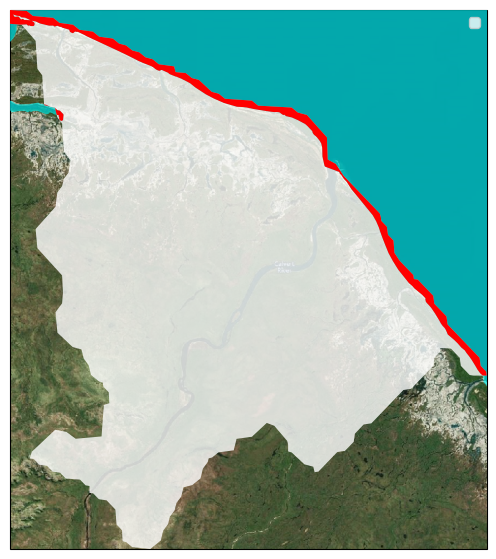

In [ ]:
# 5: Automate : the generation of the waterlevel boundary --------------------------------------------------------

# Clip the coastline to only be the one in the grid 
global_water = catalog.get_geodataframe('osm_water', geom=total_polygon)

# add buffer to ensure full coverage of coastline
global_water = global_water.buffer(0.001)  # Buffer by 0.01 degrees (~1 km)

# Direct intersection: water area within your model domain
coastal_boundary = global_water.intersection(total_polygon)

fig = plt.figure(figsize=(10,7))
ax = plt.subplot(projection=proj)
ax.add_image(cimgt.QuadtreeTiles(), 12)
total_polygon.plot(ax=ax, color='white', alpha = 0.8, label='polygon', zorder=3)
global_water.plot(ax=ax, color='cyan', alpha=0.6, label='Coastal water boundary', zorder=4)
coastal_boundary.plot(ax=ax, color='red', label='Coastal water boundary', zorder=5)
ax.set_extent(gdf_basin['geometry'].total_bounds[[0,2,1,3]], crs=proj)
ax.legend()


#  TODO: 
# Auto: Generate waterlevel boundary of geojson file -----------------------------------

# # This creates the coastal boundary as active cells 
# sf.mask.create_boundary(
#     btype='waterlevel',
#     include_polygon= coastal_boundary, # need it to be single polygon but it is multiple now with the coastlines going inland a bit 
#     reset_bounds=True
# )

# fig, ax = sf.plot_basemap(
#     variable="mask", plot_region=False, plot_bounds=False, bmap="sat", zoomlevel=12
# )


In [ ]:
# OUTFLOW BOUNDARIES - removed 

# remove outflow boundaries (check if the water accumulates near edges)
# gdf_include = sf.data_catalog.get_geodataframe(
#     "outflow_niger"
# )
# sf.mask.create_boundary(
#     btype="outflow",
#     include_polygon=gdf_include,
#     reset_bounds=True,
# # )

# # plot the shapefile given by the user as dashed line
# gdf_include.to_crs(sf.crs).boundary.plot(ax=ax, color="k", lw=1, ls="--")

In [ ]:
# TODO - doesnt work to read infiltration dataset - necessary? 

# # Infiltration data setup --------------------------------------------------------
# antecedent_moisture = 'avg' 

# sf.infiltration.create_cn(
#     'gcn250', antecedent_moisture=antecedent_moisture
# )

2026-01-14 09:16:34,816 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt


2026-01-14 09:16:43,167 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv
2026-01-14 09:16:55,968 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - WARNING - nan values in manning roughness array
2026-01-14 09:16:56,120 - hydromt.hydromt_sfincs.components.grid.roughness - roughness - INFO - Set other manning options to None in config that are unused in SFINCS in case of specifying manningfile (manning, manning_land, manning_sea, rgh_lev_land).


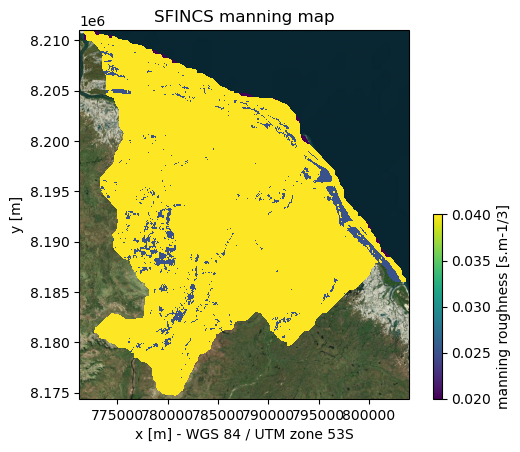

In [8]:
# Surface roughness setup --------------------------------------------------------
roughness_list = [
    {
        'lulc': 'esa_worldcover',                 # landuse/landcover dataset
        'reclass_table': 'esa_worldcover_mapping' # reclassification table
    }
]

sf.roughness.create(roughness_list)
_ = sf.plot_basemap(variable="manning", plot_bounds=False, bmap="sat", zoomlevel=12)

In [9]:
# Set up sub-grid ---------------------------------------------------------
sf.subgrid.create(
    elevation_list= elevation_list,
    roughness_list = roughness_list,
    nr_subgrid_pixels = 10,             # Fill in number of subgrid files
    write_dep_tif=True,                 # save a cloud-optimized geotiff of the subgrid topography
    write_man_tif=False,
    nrmax=5000,                         # set tile size a bit larger speed up processing (default 2000)
)

# make sure to write the updated model to the new model root before running sfincs
sf.write()

2026-01-14 09:17:09,681 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit RasterDataset data from P:\wflow_global\hydromt\topography\merit\merit.nc


2026-01-14 09:17:09,840 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gebco RasterDataset data from P:\wflow_global\hydromt\bathymetry\gebco\gebco.vrt
2026-01-14 09:17:09,897 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover RasterDataset data from P:\wflow_global\hydromt\landuse\esa_worldcover\esa-worldcover.vrt
2026-01-14 09:17:17,800 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldcover_mapping DataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\esa_worldcover_mapping.csv
2026-01-14 09:17:17,860 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of regular cells in a block : 500
2026-01-14 09:17:17,861 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of blocks in n direction    : 1
2026-01-14 09:17:17,862 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - Number of blocks in m direction    : 1
2026-01-14 09:17:17,8

In [10]:
sf.subgrid.data

# # we can plot the 2D subgrid variables
# _ = sf.plot_basemap(
#     variable=sf.subgrid.data["u_navg"], plot_bounds=False, bmap="sat", zoomlevel=12
# )

<xarray.Dataset> Size: 38MB
Dimensions:      (y: 364, x: 326, levels: 10)
Coordinates:
  * y            (y) float64 3kB 8.175e+06 8.175e+06 ... 8.211e+06 8.211e+06
  * x            (x) float64 3kB 7.714e+05 7.714e+05 ... 8.038e+05 8.038e+05
  * levels       (levels) int64 80B 0 1 2 3 4 5 6 7 8 9
    spatial_ref  int64 8B 0
Data variables: (12/18)
    z_zmin       (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    z_zmax       (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    z_volmax     (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    u_zmin       (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    u_zmax       (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    u_ffit       (y, x) float32 475kB nan nan nan nan nan ... nan nan nan nan
    ...           ...
    u_havg       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    u_nrep       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    u_pwet       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    v_havg       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    v_nrep       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    v_pwet       (levels, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
Attributes:
    _FillValue:  nan

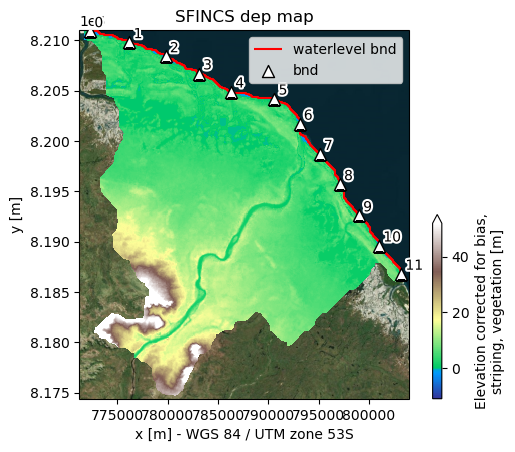

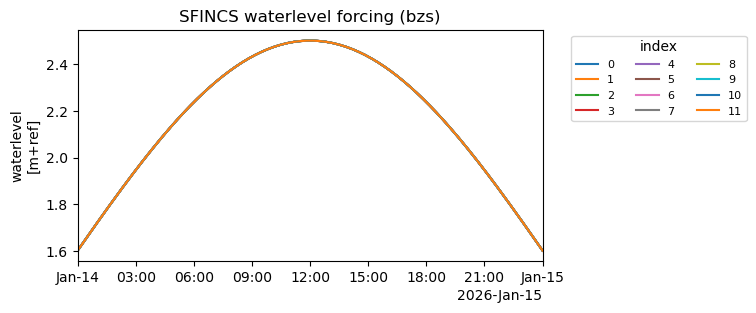

In [12]:
# 4: Add forcing --------------------------------------------------------
# Create boundary points based on mask (creates bnd points) 
sf.water_level.create_boundary_points_from_mask(bnd_dist = 5000)
fig, ax = sf.plot_basemap(variable='dep', bmap='sat', plot_bounds=True, zoomlevel=12)
ax.legend()
plt.show()

# Manually create timeseries forcing - Gaussian shape
sf.water_level.create_timeseries(
    shape = "gaussian", 
    timestep = 600, # 10 minutes in seconds
    offset = 0.0,
    peak = 2.5,
    tpeak = 3600 * 12, # peak at 12 hours
    duration = 3600 * 24 * 3 # total duration of 3 days
)

# or add gtsm here 


# Plot the forcing
_ = sf.plot_forcing()
# print(sf.water_level.data['bzs']) # prints the dataset


In [14]:
# Forcing using GTSM 
# check the bug fix from git 


# da = sf.data_catalog.get_geodataset(
#     "gtsm_codec_reanalysis_waterlevel_hourly",
#     variables=["waterlevel"],
#     bbox=sf.bbox,
#     time_range=(sf.config.get("tstart"), sf.config.get("tstop"))
# )


# sf.water_level.create(
#     data_source = 'gtsm_codec_reanalysis_waterlevel_hourly',
    
#     )

In [ ]:
# TODO Add windspeed and airpressure forcing --------------------------------------------------------

# # Windspeed
# sf.setup_wind_forcing_from_grid(
#     wind = 'era5_hourly'
# )

# # Airpressure 
# sf.setup_pressure_forcing_from_grid(
#     press='era5_hourly'
# )

# # Potentially excluding rainfall
# sf.setup_precip_forcing_from_grid(
#     precip='era5_hourly',
#     aggregate=False
# )


### Water level forcing

For the forcing of the water levels at the boundary we use the Global Tide and Surge Model (GTSM). This includes hourly waterlevels at predetermined points. To get the waterlevels at our boundary we interpolate these points to our boundary when we read in the data. The `buffer` we provide specifies the distance from our boundary to look for points in the GTSM dataset.  


In [ ]:
# TODO THIS AFTER FIGURING OUT GTSM 

# # print gtsm nc info
# ds = sf.data_catalog.get_geodataframe(
#     "gtsm_codec_reanalysis_waterlevel_hourly")

# print(ds)

# # # Plot the locations of the waterlevel points
# fig = plt.figure(figsize=(10, 7))
# ax = plt.subplot(projection=proj)
# ax.add_image(cimgt.QuadtreeTiles(), 8)

# # Plot the points
# ax.scatter(ds['lon'], ds['lat'], transform=ccrs.PlateCarree(), color='red', label='GTSM points', zorder=10)

# # Add coastlines for reference
# ax.coastlines()

# ax.legend()
# plt.show()

# # Specify the simulation time in the model config - needed? 
# sf.config.update = (
#     {
#         "tref": datetime(2023, 10, 16),
#         "tstart": datetime(2023, 10, 15),
#         "tstop": datetime(2023, 10, 18),
#     # "dtout": 3600, # map-output timestep in seconds
#     # "dthisout" : 600, # point-output timestep in seconds
#     }
# )


2026-01-14 09:20:27,096 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading merit_hydro RasterDataset data from P:\wflow_global\hydromt\topography\merit_hydro\*.vrt


(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>],
       dtype=object))

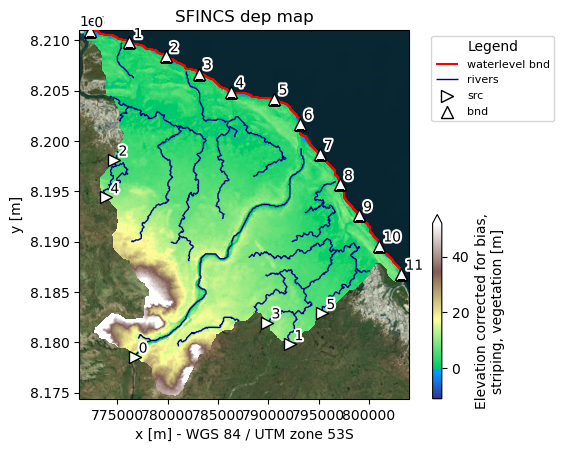

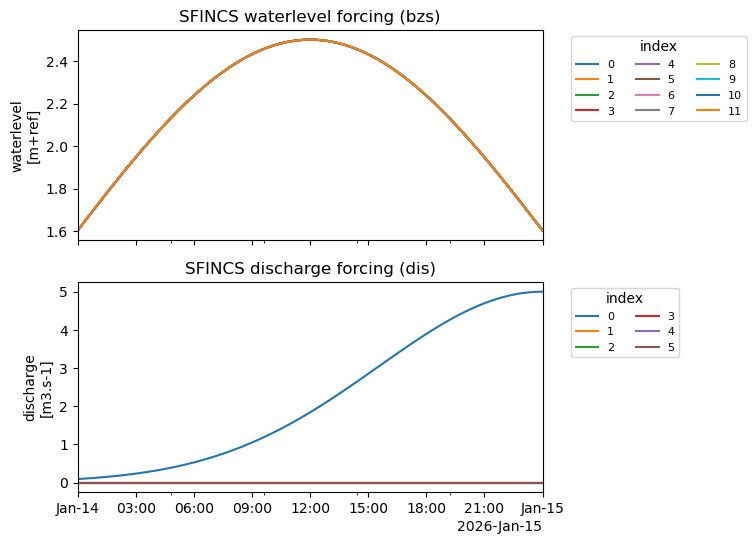

In [13]:
# Auto: Add MERIT river data --------------------------------------------------------

# Add river inflow points 
sf.rivers.create_river_inflow(
    hydrography='merit_hydro',
    river_upa=10,                   # Minimum upstream area threshold for rivers [km2], by default 10.0
    river_len=1,                    # Mimimum river length within the model domain threshhold [m], by default 1 km.
    keep_rivers_geom=True,
)

sf.plot_basemap('basemap.png', bmap='sat')

# Create own timeseires
sf.discharge_points.create_timeseries(
    index=[0],
    shape="gaussian",
    offset=0,
    peak=5,
    tpeak=86400,      # peak at day 1
    duration=2 * 86400,
    timestep=600,     # 10-min for smooth plot
)

# # Add discharge forcing - from tutorial 
# q_start = 400
# q_end = 5000
# discharge = sf.forcing['dis'].copy()
# discharge[0,3] = q_start
# discharge[1,3] = q_end
# sf.setup_discharge_forcing(discharge) # set discharge in model using hydroMT function

sf.plot_forcing()

2026-01-13 11:33:45,836 - hydromt.hydromt_sfincs.components.forcing.boundary_conditions - boundary_conditions - INFO - Removed 1 duplicate points based on 'name' or geometry.


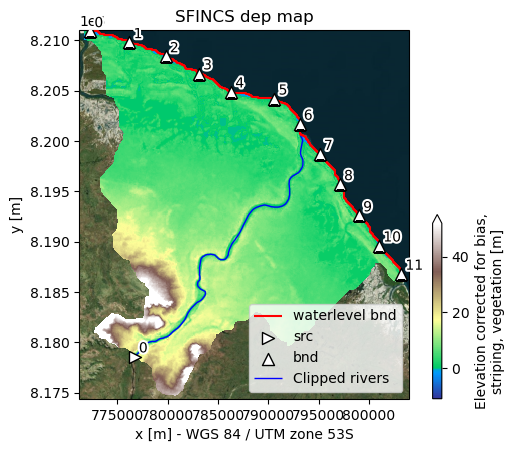

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>],
       dtype=object))

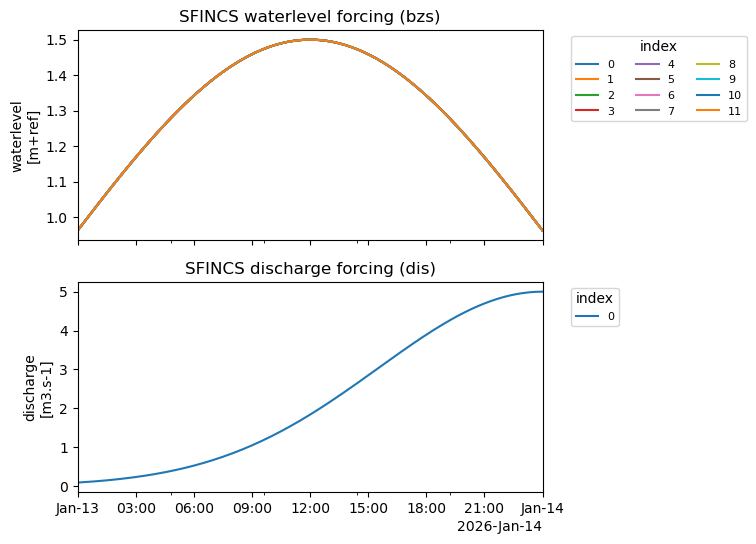

In [ ]:
# Manually:  Add rivers --------------------------------------------------------

# Load rivers manually from global_rivers dataset 
global_rivers = gpd.read_file(main_dir.joinpath("Global_rivers.gpkg"))
delta_polygon = total_polygon.to_crs(global_rivers.crs)

# Clip rivers to delta polygon
rivers_clipped = global_rivers.clip(delta_polygon.geometry)

# Get plot CRS from sfincs model (usually EPSG:3857 Web Mercator for basemaps)
target_crs = sf.crs  # or sf.model.crs

# Reproject rivers to match
rivers_clipped_plot = rivers_clipped.to_crs(target_crs)

# Create transformer from WGS84 to model CRS
transformer = Transformer.from_crs("epsg:4326", target_crs, always_xy=True)

# Transform coordinates (lon, lat order)
x, y = transformer.transform(137.591595, -16.458370)

sf.discharge_points.add_point( # this function isn't in the hydromt sfincs documentation but is in the tutorial online 
    x=x, 
    y=y, 
    value=1000.0, 
    name="inflow_point"
)

# distribution isnt gaussian 
sf.discharge_points.create_timeseries(
    index=[0],
    shape="gaussian",
    offset=0,
    peak=5,
    tpeak=86400,      # peak at day 1
    duration=2 * 86400,
    timestep=600,     # 10-min for smooth plot
)

# Now plot
sf.plot_basemap(variable="dep", 
                plot_geoms=True, 
                plot_bounds=True, 
                bmap="sat", 
                zoomlevel=12,
                legend_kwargs={'loc': 'upper center', 'bbox_to_anchor': (1, 0.5)}
)
rivers_clipped_plot.plot(ax=plt.gca(), color='blue', linewidth=1, label='Clipped rivers')
plt.legend()
plt.show()

sf.plot_forcing()

In [ ]:
# Burn the rivers into the model based on the river widths 

# Method 1: riverine depth estimated using bankfull discharge Q (need river discharge) --> Andreadis et al. (2013)
# a = 0.27  
# b = 0.30
# Q = combine_dataset['discharge'] 
# h  = a * (Q **b)

# OR 

# Method 2: depth estimated using river width --> Montgomery and Buffington (1997)
a = 0.015
b = 0.70
W = rivers_clipped['width']

rivers_clipped['depth'] = a * (W **b)

# Verify the calculation (optional)
print(rivers_clipped[['width', 'depth']].head())

        width     depth
192342   54.0  0.244775
192341  216.0  0.645965
192340  366.0  0.934390
192349  351.0  0.907416


In [14]:
# Set up observation points 
obs_points_fn = main_dir / "manual_inputs" / "aus_obs_points.geojson"

# create points
sf.observation_points.create(locations=obs_points_fn, merge=False)


2026-01-14 09:21:00,711 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading aus_obs_points.geojson GeoDataFrame data from C:\PhD\SFINCS\SFINCS_cloned\input\manual_inputs\aus_obs_points.geojson


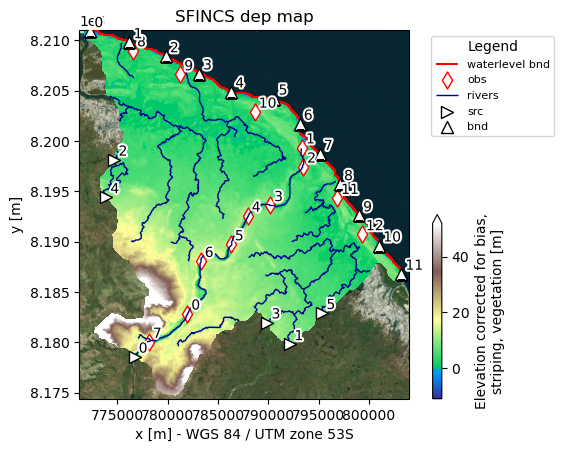

In [15]:
# Final plot of the model 
_ = sf.plot_basemap(variable='dep',bmap='sat')

In [16]:
# Save the model --------------------------------------------------------

sf.write()

In [17]:
# saving model creates a standard folder strcture that can be used to read in the mdoel 
def print_directory_tree(directory):
    directory = str(directory)
    for root, dirs, files in os.walk(directory):
        level = root.replace(directory, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            print(f"{indent}  + {f}")

print_directory_tree(str(root_folder))

sfincs_620947/
  + sfincs.bnd
  + sfincs.bzs
  + sfincs.dep
  + sfincs.dis
  + sfincs.ind
  + sfincs.inp
  + sfincs.manning
  + sfincs.msk
  + sfincs.obs
  + sfincs.scs
  + sfincs.src
  + sfincs_subgrid.nc
  figs/
    + basemap.png
  gis/
    + bnd.geojson
    + dep.tif
    + dis.geojson
    + manning.tif
    + mask.tif
    + obs.geojson
    + region.geojson
    + rivers_inflow.geojson
    + scs.tif
  subgrid/
    + dep_subgrid.tif


## **Step 7:** Running your model
We have now set up our own SFINCS model for Charleston, well done! We are now ready to run the model. In order to do so, the only thing you need to do is call the sfincs executable (located in the *bin* folder). The easiest way to do so is copy the .bat file from one of the existing Charleston models towards your new model folder. After this you can double click the .bat file and the model will start running. The logging is written to the sfincs_log.txt file. 

In [19]:
# # NOTE you need to download the SFINCS executable first (see first notebook) and update the path below
# sfincs_exe = Path("../../software", "SFINCS_v2.3.0_mt_Faber_release_exe", "sfincs.exe")

# run_sfincs(
#     sf.root, # path to the SFINCS model root folder
#     sfincs_exe=sfincs_exe, # path to the sfincs executable if you want to run SFINCS on windows
#     vm=None, # you can use 'docker' if you want to run SFINCS on linux or mac, but you need to install docker desktop first
# )

In [ ]:
# needed to create a run.bat file to run sfincs on windows
# here, i inspect it 
fn = root_folder / "run.bat"
with open(fn, "r") as f:
    txt = f.read()
print(txt)

call "C:\PhD\SFINCS\SFINCS_cloned\hydromt_sfincs\delta_model\software\SFINCS_v2.3.0_mt_Faber_release_exe\sfincs.exe">sfincs_log.txt



In [24]:
import os

# Use the dynamic root_folder based on target_basin_id instead of hardcoded path
run_path = str(root_folder)

cur_dir = os.getcwd()

# uncomment to run sfincs
os.chdir(run_path)
os.system("run.bat")
os.chdir(cur_dir)

In [25]:
fn = os.path.join(run_path, "sfincs_log.txt")
with open(fn, "r") as f:
    txt = f.read()
print(txt)


------------ Welcome to SFINCS ------------

  @@@@@  @@@@@@@ @@ @@  @@   @@@@   @@@@@
 @@@ @@@ @@@@@@@ @@ @@@ @@ @@@@@@@ @@@ @@@
 @@@     @@      @@ @@@ @@ @@   @@ @@@
  @@@@@  @@@@@@  @@ @@@@@@ @@       @@@@@
     @@@ @@      @@ @@ @@@ @@   @@     @@@
 @@@ @@@ @@      @@ @@  @@  @@@@@@ @@@ @@@
  @@@@@  @@      @@ @@   @   @@@@   @@@@@

              ..............
          ......:@@@@@@@@:......
       ..::::..@@........@@.:::::..
     ..:::::..@@..::..::..@@.::::::..
    .::::::..@@............@@.:::::::.
   .::::::..@@..............@@.:::::::.
  .::::::::..@@............@@..::::::::.
 .:::::::::...@@.@..@@..@.@@..::::::::::.
 .:::::::::...:@@@..@@..@@@:..:::::::::..
 ............@@.@@..@@..@@.@@............
 ^^^~~^^~~^^@@..............@@^^^~^^^~~^^
 .::::::::::@@..............@@.:::::::::.
  .......:.@@.....@.....@....@@.:.......
   .::....@@......@.@@@.@....@@.....::.
    .:::~@@.:...:.@@...@@.:.:.@@~::::.
     .::~@@@@@@@@@@.....@@@@@@@@@~::.
       ..:~~~~~~~:.......:~~~~~~~:.

In [ ]:
path = run_path

dir_list = os.listdir(path)

# prints all files
print(dir_list)

## **Step 8:** Inspecting the results: floodmap
Inspect the results of the model run by plotting the maximum water level on a map. In order to do so you should first read the results of the model (*sf.read_results()*). After this you can access the results by using the results attribute: *sf.results*.
The results you can plot using matplotlib.

*Tip: Print all available result keys by typing `print(sf.results.keys())`*  
*Tip:* You can also plot the results on top of the SFINCS basemap

In [30]:
# hmax is computed by SFINCS and read-in from the sfincs_map.nc file

sf.read_results()

sf.results.keys()

dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'total_runtime', 'average_dt', 'status'])

Text(0.5, 1.0, 'SFINCS maximum water depth')

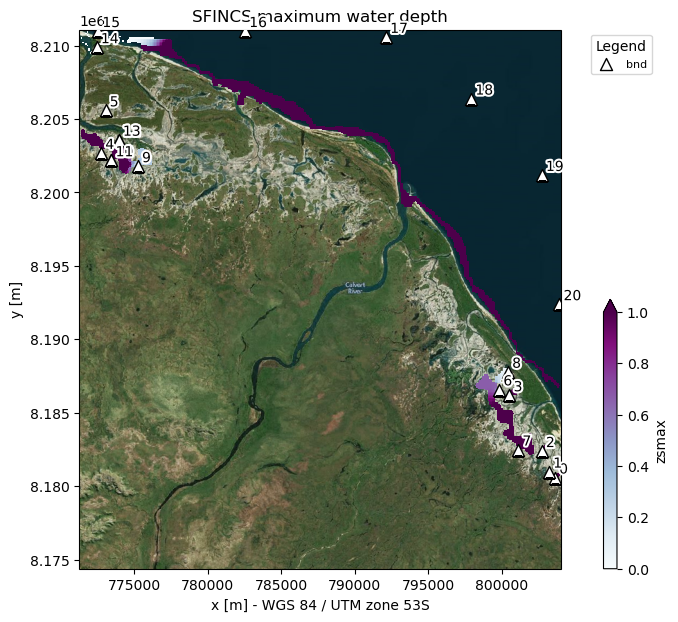

In [31]:
# variable to plot: maximum water depth
# plot_variable = <SET_PLOT_VARIABLE>
plot_variable = 'zsmax'
var = sf.results[plot_variable].max(dim='timemax').where(sf.grid['dep'] > -1)

fig, ax = sf.plot_basemap(
    fn_out="zsmax.png", # save figure to mod.root/figs/hmax.png
    variable= var, 
    plot_bounds=False,
    bmap="sat",
    zoomlevel=12,
    figsize=(11, 7),
    vmin=0, # set minimum value for colorbar
    vmax=1, # set maximum value for colorbar
    cmap="BuPu",
)

ax.set_title(f"SFINCS maximum water depth")


## **Step 9:** Inspecting the results: Timeseries
Inspect the results of the model run by plotting the waterlevels at the observation stations. The timeseries data you can access in a similar way using the results attribute of your model class. 

*Tip: Print all available result keys by typing `print(sf.results.keys())`*  

In [32]:
print(sf.results.keys())
sf.results['point_zs'].plot.line(x='time')

dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'total_runtime', 'average_dt', 'status'])


KeyError: 'point_zs'

## **Step 4:** Visualize the results on subgrid resolution

When subgrid tables are used, these are based on elevation data of a resolution higher than the resolution of the computational grid. The bed levels stored in the NetCDF output (zb in sfincs_map.nc) are the minimum bed levels from the subgrid tables of each computational cell. Therefore, to properly derive water depths, the higher resolution elevation data should be used instead of simply using the bed levels from the model output (this would result in an overestimation of flood extents). The process of interpolating the water levels onto the higher-resolution elevation data is called downscaling.

The downscaling of the floodmap roughly includees the following steps:

1. Select your high-resolution elevation dataset

2. Retrieve the maximum water levels from your model

3. Determine if and how you want to mask your floodmap

4. Write a geotiff of your downscaled floodmap

5. Plot your downscaled floodmap here, or in QGIS

More information about the downscale_floodmap function can be found here: https://deltares.github.io/hydromt_sfincs/latest/_generated/hydromt_sfincs.utils.downscale_floodmap.html


In [ ]:
# first we are going to select our subgrid-resolution elevation dataset
depfile = Path(sf.root, 'subgrid', 'dep_subgrid.tif')
dep = sf.data_catalog.get_rasterdataset(depfile)

2025-12-19 13:36:08,040 - SFINCS_log_charleston - rasterdataset - INFO - Reading  raster data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\notebook_answers\sfincs_charleston_subgrid\subgrid\dep_subgrid.tif


In [ ]:
# secondly we are reading in the model results
sf.read_results()

# now assuming we have a subgrid model, we don't have hmax available, so we are using zsmax (maximum water levels)
zsmax = sf.results["zsmax"]

# compute the maximum over all time steps
zsmax = zsmax.max(dim='timemax')

2025-12-19 13:44:28,446 - SFINCS_log_charleston - model_api - WARNING - Replacing result: inp
2025-12-19 13:44:28,447 - SFINCS_log_charleston - model_api - WARNING - Replacing result: msk
2025-12-19 13:44:28,448 - SFINCS_log_charleston - model_api - WARNING - Replacing result: qinf
2025-12-19 13:44:28,450 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zb
2025-12-19 13:44:28,451 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zs
2025-12-19 13:44:28,452 - SFINCS_log_charleston - model_api - WARNING - Replacing result: zsmax
2025-12-19 13:44:28,453 - SFINCS_log_charleston - model_api - WARNING - Replacing result: total_runtime
2025-12-19 13:44:28,454 - SFINCS_log_charleston - model_api - WARNING - Replacing result: average_dt
2025-12-19 13:44:28,455 - SFINCS_log_charleston - model_api - WARNING - Replacing result: status


In [ ]:
# uncomment to check method docstring for more info
# utils.downscale_floodmap?

In [ ]:
# Thirdly, we downscale the floodmap and write it to a geotiff
gdf_osm = sf.data_catalog.get_geodataframe('osm_landareas')
floodmap_fn=Path(model_root, "subgrid", "floodmap.tif")

hmax = utils.downscale_floodmap(
    zsmax=zsmax,
    dep=dep,
    hmin=0.10,
    # gdf_mask=gdf_osm,  #you can turn this on
    floodmap_fn=floodmap_fn,
    logger=logger,
)

2025-12-19 13:45:13,128 - SFINCS_log_charleston - geodataframe - INFO - Reading osm_landareas vector data from c:\PhD\SFINCS\SFINCS_Charleston\02_hands-on\local_data\osm_landareas.gpkg
2025-12-19 13:45:15,174 - SFINCS_log_charleston - utils - INFO - Building 4 overviews with nearest


We know created a geotif file with the downscaled floodmaps. With the function below we can view the geotif interactively within the notebook. Fill in the path of your geotif and run the cell below. 

*Hint* you can ignore the error message that the holoviews function gives.

In [ ]:
# # View the floodmap interactively
# make_interactive_plot(
#     da_fn=floodmap_fn,
#     bmap='Satellite',
#     title='TITLE', 
#     vmax=3
# )

### Question 2

2a) Check the size of the cells, does it agree with your expectation?

2b) Why do you think if you zoom in, the results on land look less smooth and 'tiled'?

2c) Can you identify from the floodmap where the high resolution topography data ends?

2d) You can mask the flood map so you only see data on land, as known by OpenStreetMaps, by including the line 'gdf_mask=gdf_osm' in downscale_floodmap, does this match your expectation?

#### Fill in your own answers:

2a)

2b)

2c)

2d)

### IMPORTANT NOTE 
While it's great that you can very quickly run a SFINCS simulation on a course 200 m grid, and downscale the final floodmap to e.g. 1m resolution that looks pretty, the original simulation was still relatively course, despite using the subgrid functionality.

In your own project, always look whether the level of you detail you need to resolve matches with your flux grid resolution.
You might want the increase the resolution (and wait a little bit longer on the outcome of your simulation.)